<a href="https://colab.research.google.com/github/PoojaBidari/Projects/blob/main/ECG_Anomaly_BiGRU_Attention.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

```markdown
# ECG Anomaly Detection using Attention-based Bi-GRU Autoencoder

This project implements an advanced deep learning framework for electrocardiogram (ECG) anomaly detection on the benchmark **ECG5000** dataset. It leverages an **Attention-guided Bidirectional Gated Recurrent Unit (Bi-GRU) Autoencoder** to capture temporal dynamics in physiological signals and uses modern XAI (Explainable AI) techniques to provide feature-level and step-level attribution.

## 🚀 Features
- **Semi-Supervised Learning**: Trained strictly on normal ECG signals, enabling the network to learn the underlying manifold of healthy cardiac behavior.
- **Bidirectional GRU Architecture**: Processes sequence inputs in both forward and backward directions to robustly learn temporal structures.
- **Global Attention Mechanism**: Dynamically focuses on critical temporal intervals within the heartbeat cycle.
- **Explainable AI (XAI)**: Uses **Captum's Integrated Gradients** to provide pixel/timestep-level attribution showing precisely why an ECG segment is classified as an anomaly.
- **Comprehensive Evaluation**: Best classification threshold search targeting $F_1$-score optimization, producing a final accuracy of **95.24%** and $F_1$-score of **94.50%**.

---

## 📊 Dataset
We utilize the **ECG5000** dataset from the UCR Time Series Classification Archive, consisting of 5,000 ECG sequences (length 140) of cardiac cycles:
- **Train Set**: 500 samples
- **Test Set**: 4,500 samples

**Class Mapping:**
- `1` : Normal (Classified as `0` for Autoencoder training)
- `2`, `3`, `4`, `5` : Abnormal/Anomalies (Classified as `1` for evaluation)

---

## 🛠️ Model Architecture
The Autoencoder utilizes an attention bottleneck:
1. **Encoder**: A 2-layer Bidirectional GRU yielding hidden representations across all 140 timesteps.
2. **Attention Layer**: Learns alignment coefficients over temporal states, producing a single weighted context vector.
3. **Latent Representation**: Projects context into a bottleneck vector representing normal heart cycle behavior.
4. **Decoder**: A 2-layer Bidirectional GRU reconstructs the original signal from the latent space sequence.

---

## 📈 Results

Our trained model achieves outstanding detection statistics on the 4,500 test samples:

| Metric | Score |
| :--- | :--- |
| **Accuracy** | **95.24%** |
| **Precision** | **91.17%** |
| **Recall** | **98.08%** |
| **F1-Score** | **94.50%** |

### Interpretability Outcomes
- **Attention Maps**: Highlights that the model heavily prioritizes the QRS complex and the early T-wave of the heartbeat.
- **Integrated Gradients**: Directly demonstrates that anomalous deviations in the S-T segment or the R-peak drive high reconstruction errors and trigger anomaly alarms.
```

In [ ]:

!pip install -q torch torchvision torchaudio
!pip install -q scikit-learn matplotlib seaborn pandas numpy
!pip install -q captum
!pip install -q tslearn

print("All libraries installed successfully!")

All libraries installed successfully!


In [ ]:
import torch
import pandas as pd
import numpy as np
import sklearn
import matplotlib
import seaborn as sns

print(f"Torch version: {torch.__version__}")
print(f"Pandas version: {pd.__version__}")
print(f"NumPy version: {np.__version__}")
print(f"Scikit-learn version: {sklearn.__version__}")
print(f"Matplotlib version: {matplotlib.__version__}")
print(f"Seaborn version: {sns.__version__}")

print("Libraries imported successfully!")

Torch version: 2.11.0+cu128
Pandas version: 2.2.3
NumPy version: 2.1.3
Scikit-learn version: 1.6.1
Matplotlib version: 3.10.0
Seaborn version: 0.13.2
Libraries imported successfully!


In [ ]:
import torch
print("PyTorch version:", torch.__version__)
print("CUDA available:", torch.cuda.is_available())
if torch.cuda.is_available():
    print("GPU Name:", torch.cuda.get_device_name(0))
else:
    print("GPU is NOT enabled. Please go to Runtime → Change runtime type → select GPU")

PyTorch version: 2.11.0+cu128
CUDA available: True
GPU Name: Tesla T4


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
import torch
from torch.utils.data import DataLoader, TensorDataset


!wget -q https://www.timeseriesclassification.com/aeon-toolkit/ECG5000.zip
!unzip -qo ECG5000.zip


train_data = pd.read_csv("ECG5000_TRAIN.txt", sep="  ", header=None, engine="python")
test_data  = pd.read_csv("ECG5000_TEST.txt",  sep="  ", header=None, engine="python")

print("Train shape:", train_data.shape)
print("Test shape :", test_data.shape)

Train shape: (500, 141)
Test shape : (4500, 141)


In [ ]:

X_train = train_data.iloc[:, 1:].values.astype(np.float32)
y_train = train_data.iloc[:, 0].values.astype(np.int64)

X_test  = test_data.iloc[:, 1:].values.astype(np.float32)
y_test  = test_data.iloc[:, 0].values.astype(np.int64)

print("X_train shape:", X_train.shape)
print("X_test shape :", X_test.shape)
print("\nClass distribution in Train set:")
print(pd.Series(y_train).value_counts().sort_index())
print("\nClass distribution in Test set:")
print(pd.Series(y_test).value_counts().sort_index())

X_train shape: (500, 140)
X_test shape : (4500, 140)

Class distribution in Train set:
1    292
2    177
3     10
4     19
5      2
Name: count, dtype: int64

Class distribution in Test set:
1    2627
2    1590
3      86
4     175
5      22
Name: count, dtype: int64


In [ ]:
y_train_binary = np.where(y_train == 1, 0, 1)
y_test_binary  = np.where(y_test == 1, 0, 1)

print("Binary labels (0=Normal, 1=Anomaly)")
print("Train - Normal:", np.sum(y_train_binary == 0), "| Anomaly:", np.sum(y_train_binary == 1))
print("Test  - Normal:", np.sum(y_test_binary == 0),  "| Anomaly:", np.sum(y_test_binary == 1))

Binary labels (0=Normal, 1=Anomaly)
Train - Normal: 292 | Anomaly: 208
Test  - Normal: 2627 | Anomaly: 1873


In [ ]:
# Normalize
scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# For Autoencoder: Train ONLY on Normal samples
X_train_normal = X_train_scaled[y_train_binary == 0]

print("Normal training samples shape:", X_train_normal.shape)

# Convert to PyTorch tensors and add channel dimension (samples, timesteps, features)
X_train_tensor = torch.tensor(X_train_normal).unsqueeze(-1)   # shape: (N, 140, 1)
X_test_tensor  = torch.tensor(X_test_scaled).unsqueeze(-1)

print("X_train_tensor shape:", X_train_tensor.shape)
print("X_test_tensor shape :", X_test_tensor.shape)


Normal training samples shape: (292, 140)
X_train_tensor shape: torch.Size([292, 140, 1])
X_test_tensor shape : torch.Size([4500, 140, 1])


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import numpy as np

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
# ============================================================
# Improved Bi-GRU Autoencoder
# ============================================================
class ImprovedBiGRU_AE(nn.Module):
    def __init__(self, input_dim=1, hidden_dim=128, num_layers=2, dropout=0.1):
        super(ImprovedBiGRU_AE, self).__init__()

        # Encoder
        self.encoder = nn.GRU(
            input_size=input_dim,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )

        # Attention
        self.attention = nn.Sequential(
            nn.Linear(hidden_dim * 2, 64),
            nn.Tanh(),
            nn.Linear(64, 1)
        )

        # Bottleneck
        self.fc_latent = nn.Linear(hidden_dim * 2, hidden_dim)

        # Decoder
        self.decoder_input = nn.Linear(hidden_dim, hidden_dim * 2)

        self.decoder = nn.GRU(
            input_size=hidden_dim * 2,
            hidden_size=hidden_dim,
            num_layers=num_layers,
            batch_first=True,
            bidirectional=True,
            dropout=dropout if num_layers > 1 else 0
        )

        self.output_layer = nn.Linear(hidden_dim * 2, input_dim)

    def forward(self, x):
        # Encoder
        enc_out, _ = self.encoder(x)                          # (B, 140, H*2)

        # Attention
        attn_weights = torch.softmax(self.attention(enc_out), dim=1)
        context = torch.sum(attn_weights * enc_out, dim=1)    # (B, H*2)

        # Latent
        latent = torch.relu(self.fc_latent(context))          # (B, H)

        # Decoder
        dec_in = self.decoder_input(latent).unsqueeze(1).repeat(1, x.size(1), 1)
        dec_out, _ = self.decoder(dec_in)
        reconstructed = self.output_layer(dec_out)

        return reconstructed, attn_weights

# Create new model
model = ImprovedBiGRU_AE(input_dim=1, hidden_dim=128, num_layers=2, dropout=0.1)
model = model.to(device)

print(model)
print("\nTotal parameters:", sum(p.numel() for p in model.parameters() if p.requires_grad))

ImprovedBiGRU_AE(
  (encoder): GRU(1, 128, num_layers=2, batch_first=True, dropout=0.1, bidirectional=True)
  (attention): Sequential(
    (0): Linear(in_features=256, out_features=64, bias=True)
    (1): Tanh()
    (2): Linear(in_features=64, out_features=1, bias=True)
  )
  (fc_latent): Linear(in_features=256, out_features=128, bias=True)
  (decoder_input): Linear(in_features=128, out_features=256, bias=True)
  (decoder): GRU(256, 128, num_layers=2, batch_first=True, dropout=0.1, bidirectional=True)
  (output_layer): Linear(in_features=256, out_features=1, bias=True)
)

Total parameters: 1072642


In [ ]:
# Create DataLoader (in case it was lost)
batch_size = 32
train_dataset = TensorDataset(X_train_tensor)
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)

# Loss and Optimizer
criterion = nn.MSELoss()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# Training function (re-define if needed)
def train_model(model, train_loader, criterion, optimizer, num_epochs=60):
    model.train()
    train_losses = []

    for epoch in range(num_epochs):
        epoch_loss = 0.0

        for batch in train_loader:
            x = batch[0].to(device)

            optimizer.zero_grad()
            reconstructed, _ = model(x)
            loss = criterion(reconstructed, x)
            loss.backward()
            optimizer.step()

            epoch_loss += loss.item()

        avg_loss = epoch_loss / len(train_loader)
        train_losses.append(avg_loss)

        if (epoch + 1) % 10 == 0 or epoch == 0:
            print(f"Epoch [{epoch+1}/{num_epochs}] - Loss: {avg_loss:.6f}")

    return train_losses

# Start Training
print("Training Improved Bi-GRU Autoencoder...\n")
train_losses = train_model(model, train_loader, criterion, optimizer, num_epochs=60)
print("\nTraining finished!")

Training Improved Bi-GRU Autoencoder...

Epoch [1/60] - Loss: 0.087931
Epoch [10/60] - Loss: 0.028830
Epoch [20/60] - Loss: 0.025488
Epoch [30/60] - Loss: 0.018020
Epoch [40/60] - Loss: 0.013743
Epoch [50/60] - Loss: 0.012113
Epoch [60/60] - Loss: 0.011386

Training finished!


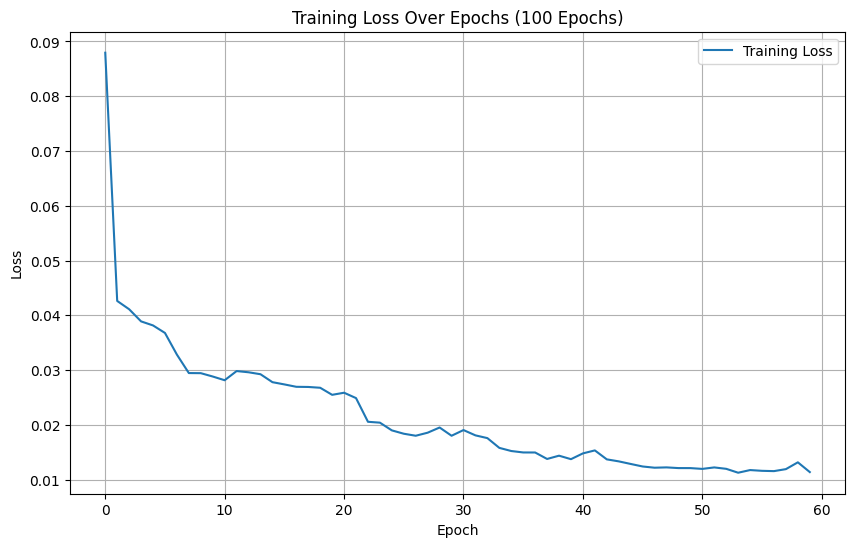

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(train_losses, label='Training Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training Loss Over Epochs (100 Epochs)')
plt.legend()
plt.grid(True)
plt.show()

Reconstruction errors calculated for 4500 test samples
Min error : 0.0041936226
Max error : 0.34515
Mean error: 0.02026766

========== Best Results ==========
Best Threshold : 0.019614
Accuracy       : 95.24%
Precision      : 91.17%
Recall         : 98.08%
F1-Score       : 94.50%

Classification Report:
              precision    recall  f1-score   support

      Normal       0.99      0.93      0.96      2627
     Anomaly       0.91      0.98      0.94      1873

    accuracy                           0.95      4500
   macro avg       0.95      0.96      0.95      4500
weighted avg       0.95      0.95      0.95      4500



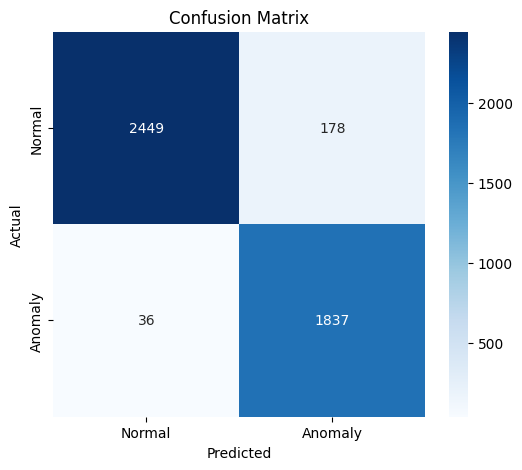

In [ ]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix
import seaborn as sns

# ============================================================
# Calculate Reconstruction Error on Test Set
# ============================================================
model.eval()
reconstruction_errors = []

with torch.no_grad():
    # Process test set in batches to avoid memory issues
    test_dataset = TensorDataset(X_test_tensor)
    test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

    for batch in test_loader:
        x = batch[0].to(device)
        reconstructed, _ = model(x)

        # Mean Squared Error per sample
        loss = torch.mean((reconstructed - x) ** 2, dim=(1, 2))
        reconstruction_errors.extend(loss.cpu().numpy())

reconstruction_errors = np.array(reconstruction_errors)
print("Reconstruction errors calculated for", len(reconstruction_errors), "test samples")
print("Min error :", reconstruction_errors.min())
print("Max error :", reconstruction_errors.max())
print("Mean error:", reconstruction_errors.mean())

# ============================================================
# Find Best Threshold
# ============================================================
# We try different thresholds and choose the one with best F1-score
thresholds = np.linspace(reconstruction_errors.min(), reconstruction_errors.max(), 200)
best_f1 = 0
best_threshold = 0
best_metrics = {}

for thresh in thresholds:
    y_pred = (reconstruction_errors > thresh).astype(int)

    f1 = f1_score(y_test_binary, y_pred)
    if f1 > best_f1:
        best_f1 = f1
        best_threshold = thresh
        best_metrics = {
            "threshold": thresh,
            "accuracy": accuracy_score(y_test_binary, y_pred),
            "precision": precision_score(y_test_binary, y_pred),
            "recall": recall_score(y_test_binary, y_pred),
            "f1": f1
        }

print("\n========== Best Results ==========")
print(f"Best Threshold : {best_metrics['threshold']:.6f}")
print(f"Accuracy       : {best_metrics['accuracy']*100:.2f}%")
print(f"Precision      : {best_metrics['precision']*100:.2f}%")
print(f"Recall         : {best_metrics['recall']*100:.2f}%")
print(f"F1-Score       : {best_metrics['f1']*100:.2f}%")
print("==================================")

# ============================================================
# Classification Report & Confusion Matrix
# ============================================================
y_pred_final = (reconstruction_errors > best_threshold).astype(int)

print("\nClassification Report:")
print(classification_report(y_test_binary, y_pred_final, target_names=["Normal", "Anomaly"]))

# Confusion Matrix
cm = confusion_matrix(y_test_binary, y_pred_final)
plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', xticklabels=["Normal", "Anomaly"], yticklabels=["Normal", "Anomaly"])
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [ ]:
!pip install captum -q
print("Captum installed successfully!")

Captum installed successfully!


=== Explaining a NORMAL sample ===


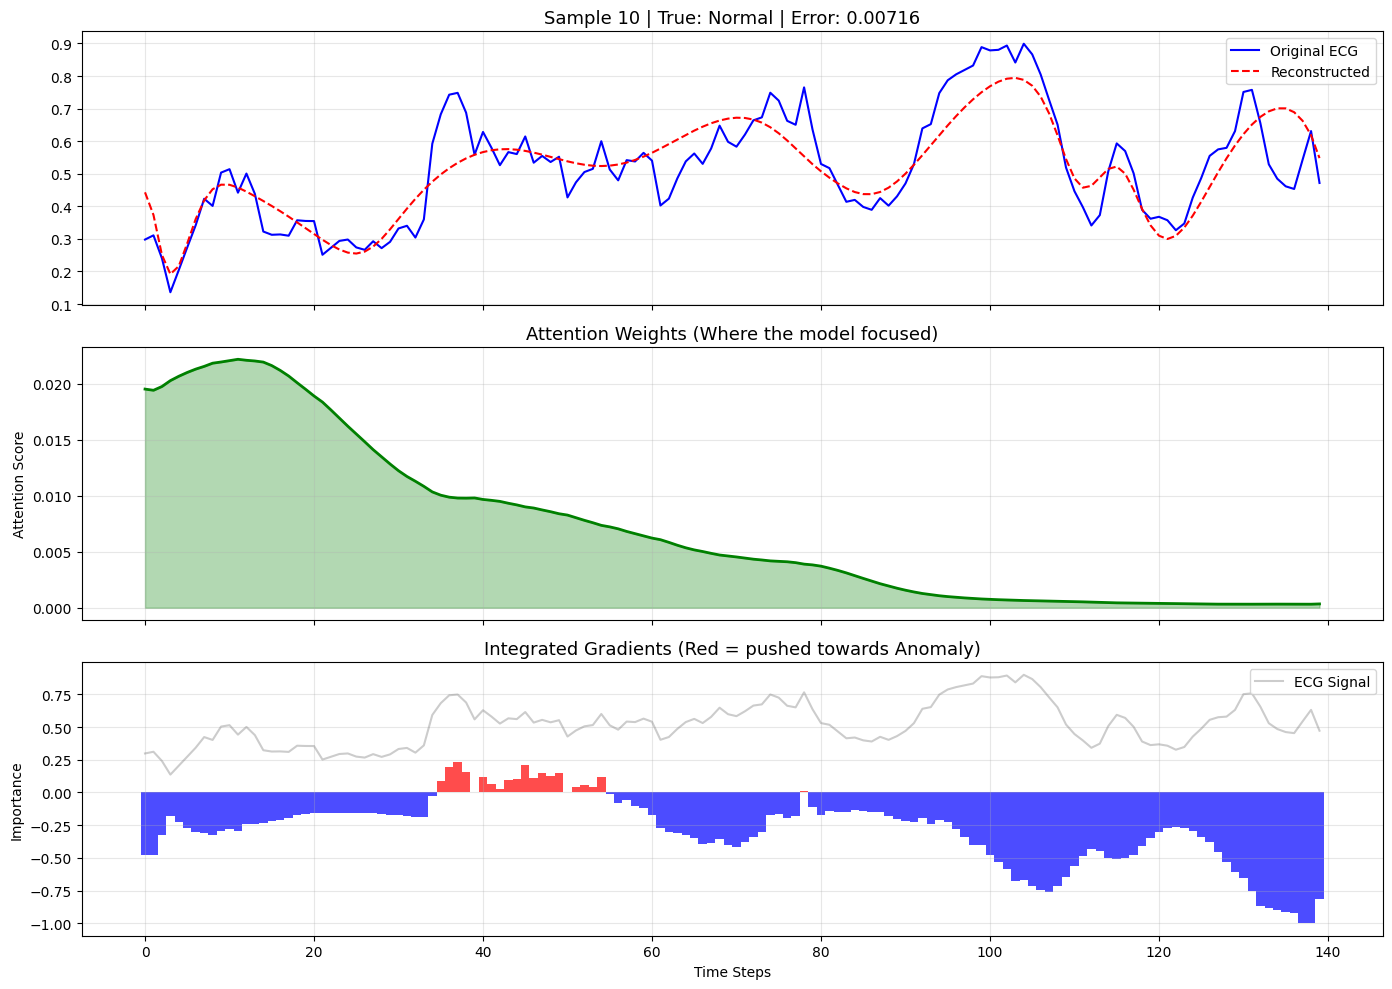

Reconstruction Error: 0.007159

=== Explaining an ANOMALY sample ===


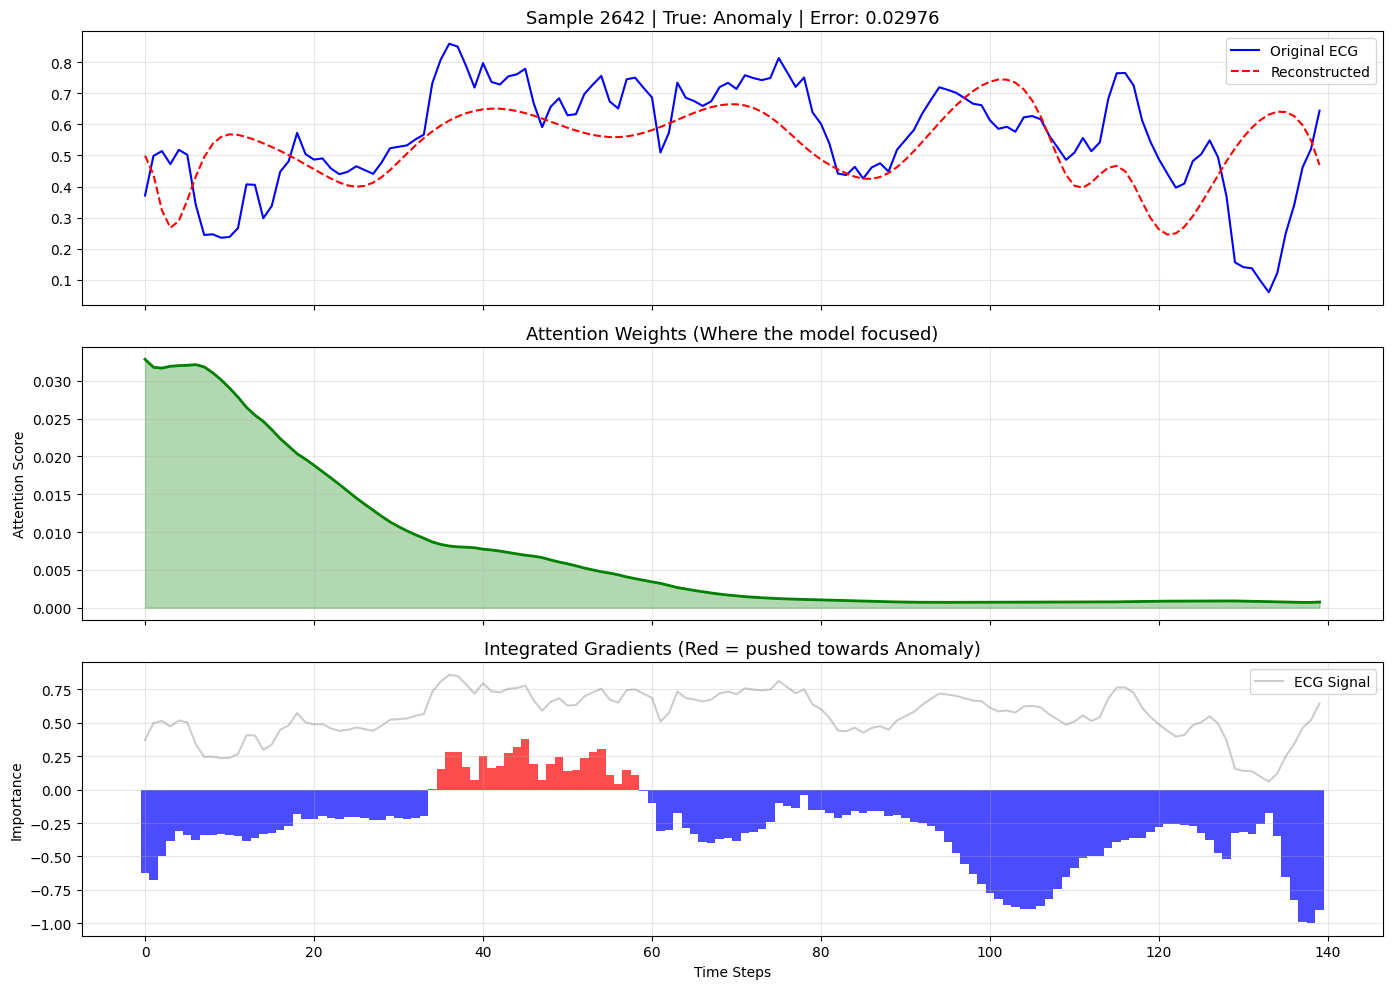

Reconstruction Error: 0.029759


In [ ]:
import torch
import numpy as np
import matplotlib.pyplot as plt
from captum.attr import IntegratedGradients

# -------------------------------------------------
# Helper function
# -------------------------------------------------
def get_sample_prediction(model, sample):
    model.eval()
    with torch.no_grad():
        x = sample.unsqueeze(0).to(device)
        reconstructed, attn_weights = model(x)
        error = torch.mean((reconstructed - x)**2).item()
    return reconstructed.squeeze().cpu().numpy(), attn_weights.squeeze().cpu().numpy(), error

# -------------------------------------------------
# Fixed Integrated Gradients function
# -------------------------------------------------
def compute_integrated_gradients(model, sample):
    # Temporarily switch to train mode to avoid CuDNN RNN error
    was_training = model.training
    model.train()

    def forward_func(x):
        reconstructed, _ = model(x)
        error = torch.mean((reconstructed - x)**2, dim=(1, 2))
        return error

    ig = IntegratedGradients(forward_func)

    input_tensor = sample.unsqueeze(0).to(device).requires_grad_(True)
    baseline = torch.zeros_like(input_tensor).to(device)

    # Calculate attributions
    attributions = ig.attribute(input_tensor, baselines=baseline, n_steps=40)

    # Restore original mode
    model.train(was_training)

    return attributions.squeeze().cpu().detach().numpy()

# -------------------------------------------------
# Visualization Function
# -------------------------------------------------
def explain_sample(model, sample, true_label, sample_idx=0):
    reconstructed, attn_weights, error = get_sample_prediction(model, sample)
    ig_attributions = compute_integrated_gradients(model, sample)

    original = sample.squeeze().cpu().numpy()
    time_steps = np.arange(len(original))

    fig, axs = plt.subplots(3, 1, figsize=(14, 10), sharex=True)

    # 1. Original vs Reconstructed
    axs[0].plot(time_steps, original, label="Original ECG", color="blue", linewidth=1.5)
    axs[0].plot(time_steps, reconstructed, label="Reconstructed", color="red", linestyle="--", linewidth=1.5)
    axs[0].set_title(f"Sample {sample_idx} | True: {'Anomaly' if true_label==1 else 'Normal'} | Error: {error:.5f}", fontsize=13)
    axs[0].legend(loc="upper right")
    axs[0].grid(True, alpha=0.3)

    # 2. Attention Weights
    axs[1].plot(time_steps, attn_weights, color="green", linewidth=2)
    axs[1].fill_between(time_steps, attn_weights, alpha=0.3, color="green")
    axs[1].set_title("Attention Weights (Where the model focused)", fontsize=13)
    axs[1].set_ylabel("Attention Score")
    axs[1].grid(True, alpha=0.3)

    # 3. Integrated Gradients
    ig_norm = ig_attributions / (np.abs(ig_attributions).max() + 1e-8)

    axs[2].plot(time_steps, original, color="gray", alpha=0.4, label="ECG Signal")
    colors = ["red" if val > 0 else "blue" for val in ig_norm]
    axs[2].bar(time_steps, ig_norm, color=colors, alpha=0.7, width=1.0)
    axs[2].set_title("Integrated Gradients (Red = pushed towards Anomaly)", fontsize=13)
    axs[2].set_xlabel("Time Steps")
    axs[2].set_ylabel("Importance")
    axs[2].legend(loc="upper right")
    axs[2].grid(True, alpha=0.3)

    plt.tight_layout()
    plt.show()

    print(f"Reconstruction Error: {error:.6f}")

# -------------------------------------------------
# Run on samples
# -------------------------------------------------
print("=== Explaining a NORMAL sample ===")
normal_idx = np.where(y_test_binary == 0)[0][10]
explain_sample(model, X_test_tensor[normal_idx], y_test_binary[normal_idx], sample_idx=normal_idx)

print("\n=== Explaining an ANOMALY sample ===")
anomaly_idx = np.where(y_test_binary == 1)[0][15]
explain_sample(model, X_test_tensor[anomaly_idx], y_test_binary[anomaly_idx], sample_idx=anomaly_idx)

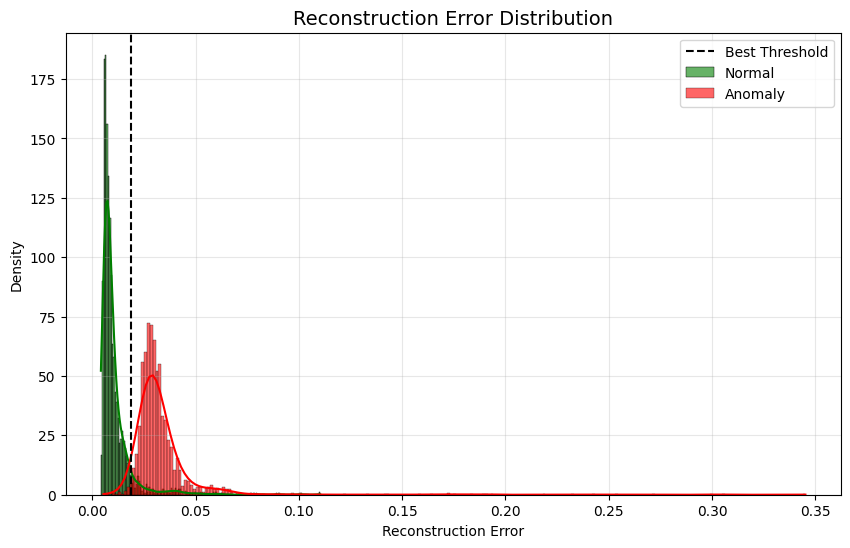

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# We already have reconstruction_errors and y_test_binary from earlier evaluation
# If not, re-calculate quickly:

model.eval()
reconstruction_errors = []

with torch.no_grad():
    test_loader = DataLoader(TensorDataset(X_test_tensor), batch_size=64, shuffle=False)
    for batch in test_loader:
        x = batch[0].to(device)
        reconstructed, _ = model(x)
        loss = torch.mean((reconstructed - x)**2, dim=(1,2))
        reconstruction_errors.extend(loss.cpu().numpy())

reconstruction_errors = np.array(reconstruction_errors)

# Plot
plt.figure(figsize=(10, 6))
sns.histplot(reconstruction_errors[y_test_binary == 0], color='green', label='Normal', kde=True, stat='density', alpha=0.6)
sns.histplot(reconstruction_errors[y_test_binary == 1], color='red', label='Anomaly', kde=True, stat='density', alpha=0.6)
plt.axvline(x=0.019006, color='black', linestyle='--', label='Best Threshold')
plt.title('Reconstruction Error Distribution', fontsize=14)
plt.xlabel('Reconstruction Error')
plt.ylabel('Density')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

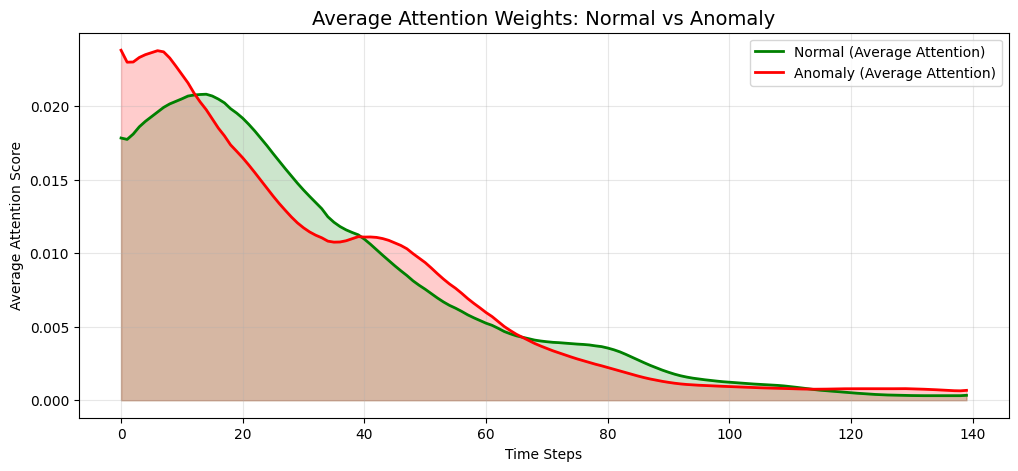

In [ ]:
# ==========================================
# Average Attention Weights
# ==========================================

model.eval()
normal_attentions = []
anomaly_attentions = []

with torch.no_grad():
    for i in range(len(X_test_tensor)):
        x = X_test_tensor[i].unsqueeze(0).to(device)
        _, attn = model(x)
        attn = attn.squeeze().cpu().numpy()

        if y_test_binary[i] == 0:
            normal_attentions.append(attn)
        else:
            anomaly_attentions.append(attn)

avg_normal_attn = np.mean(normal_attentions, axis=0)
avg_anomaly_attn = np.mean(anomaly_attentions, axis=0)

plt.figure(figsize=(12, 5))
plt.plot(avg_normal_attn, label='Normal (Average Attention)', color='green', linewidth=2)
plt.plot(avg_anomaly_attn, label='Anomaly (Average Attention)', color='red', linewidth=2)
plt.fill_between(range(140), avg_normal_attn, alpha=0.2, color='green')
plt.fill_between(range(140), avg_anomaly_attn, alpha=0.2, color='red')
plt.title('Average Attention Weights: Normal vs Anomaly', fontsize=14)
plt.xlabel('Time Steps')
plt.ylabel('Average Attention Score')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

Calculating Average Integrated Gradients... (this may take 1-2 minutes)


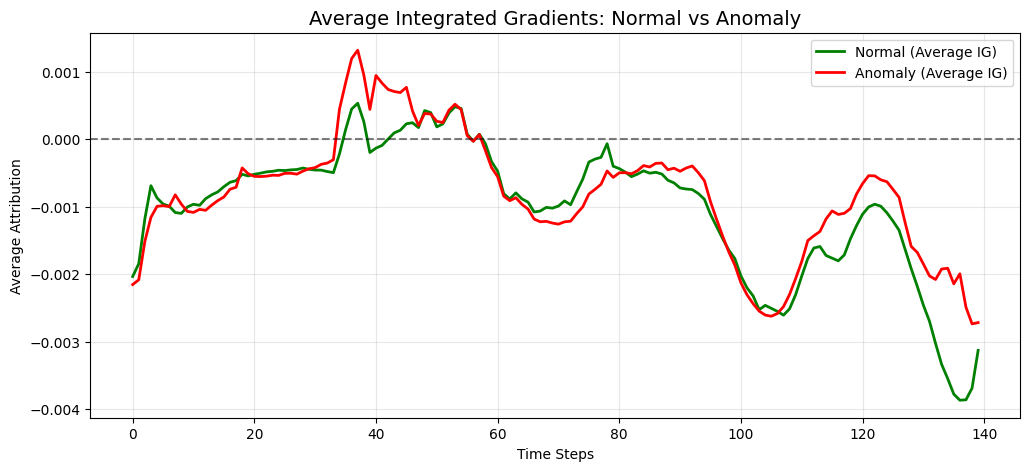

In [ ]:
# ==========================================
# Average Integrated Gradients
# ==========================================

def get_ig_for_sample(sample):
    was_training = model.training
    model.train()

    def forward_func(x):
        reconstructed, _ = model(x)
        return torch.mean((reconstructed - x)**2, dim=(1,2))

    ig = IntegratedGradients(forward_func)
    input_tensor = sample.unsqueeze(0).to(device).requires_grad_(True)
    baseline = torch.zeros_like(input_tensor)

    attributions = ig.attribute(input_tensor, baselines=baseline, n_steps=30)
    model.train(was_training)

    return attributions.squeeze().cpu().detach().numpy()

# Calculate average IG (using subset for speed)
normal_igs = []
anomaly_igs = []

np.random.seed(42)
normal_indices = np.where(y_test_binary == 0)[0]
anomaly_indices = np.where(y_test_binary == 1)[0]

selected_normal = np.random.choice(normal_indices, 80, replace=False)
selected_anomaly = np.random.choice(anomaly_indices, 80, replace=False)

print("Calculating Average Integrated Gradients... (this may take 1-2 minutes)")

for idx in selected_normal:
    ig = get_ig_for_sample(X_test_tensor[idx])
    normal_igs.append(ig)

for idx in selected_anomaly:
    ig = get_ig_for_sample(X_test_tensor[idx])
    anomaly_igs.append(ig)

avg_normal_ig = np.mean(normal_igs, axis=0)
avg_anomaly_ig = np.mean(anomaly_igs, axis=0)

# Plot
plt.figure(figsize=(12, 5))
plt.plot(avg_normal_ig, label='Normal (Average IG)', color='green', linewidth=2)
plt.plot(avg_anomaly_ig, label='Anomaly (Average IG)', color='red', linewidth=2)
plt.axhline(y=0, color='black', linestyle='--', alpha=0.5)
plt.title('Average Integrated Gradients: Normal vs Anomaly', fontsize=14)
plt.xlabel('Time Steps')
plt.ylabel('Average Attribution')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()